# Dampak Diskon terhadap Profit Margin

## Metodologi

1. Menghitung total transaksi, sales, dan profit pada setiap tingkat diskon.
2. Menghitung profit margin.
3. Memfilter data untuk transaksi di atas 20.
4. Menampilkan dampak diskon terhadap profit margin dalam bentuk grafik.

## Persiapan Data dan Library

Mengimpor library yang dibutuhkan dan memuat dataset untuk proses analisis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action='ignore', category=FutureWarning)

df = pd.read_csv('superstore_2017.csv')

## Hitung Total Transaksi, Sales, dan Profit

Data dikelompokkan berdasarkan kategori dan tingkat diskon, kemudian dihitung total transaksi, sales, dan profit.

In [2]:
df_agg = df.groupby(['category', 'discount']).agg(transaction=('order_id', 'count'), sales=('sales', 'sum'),
                                                  profit=('profit','sum'))
df_agg.index = df_agg.index.set_levels(df_agg.index.levels[1].astype(int), level=1)

df_agg

transaction        sales      profit
category        discount                                      
Furniture       0                 274   72337.7300  16260.3459
                10                 25   15458.9490   2450.0482
                15                 16    8762.7945    537.5329
                20                204   58358.4480   1282.3907
                30                 67   31096.9120  -3876.6016
                32                 11    3717.1112   -492.2300
                40                 24   15654.0360  -5418.1380
                45                  4    2509.6115  -1228.4406
                50                 15    4336.7650  -2716.7899
                60                 39    2039.6320  -1968.8777
                70                  7    1115.2800  -1810.8486
Office Supplies 0                1033  147089.2800  43362.6776
                10                  1      87.4440     18.4604
                20                736   84301.2000  14793.0690
                70                125    6789.5010  -5193.1215
                80                107    7829.7500 -13244.4638
Technology      0                 282  129099.1800  44432.5027
                10                  2    3410.9550    832.0843
                20                282  106246.5760  16861.2322
                30                  1     209.9860      8.9994
                40                 45   18446.0160  -2415.0081
                50                  4    9464.6800  -4147.5984
                70                  6    4152.7140  -5066.7810

## Hitung Profit Margin

Profit margin dihitung dengan membagi profit terhadap sales, kemudian dikalikan 100 untuk memperoleh persentase.

In [3]:
df_agg['profit_margin'] = df_agg['profit'].div(df_agg['sales']).mul(100)

df_agg

transaction        sales      profit  profit_margin
category        discount                                                     
Furniture       0                 274   72337.7300  16260.3459      22.478375
                10                 25   15458.9490   2450.0482      15.848737
                15                 16    8762.7945    537.5329       6.134263
                20                204   58358.4480   1282.3907       2.197438
                30                 67   31096.9120  -3876.6016     -12.466195
                32                 11    3717.1112   -492.2300     -13.242273
                40                 24   15654.0360  -5418.1380     -34.611764
                45                  4    2509.6115  -1228.4406     -48.949433
                50                 15    4336.7650  -2716.7899     -62.645541
                60                 39    2039.6320  -1968.8777     -96.531026
                70                  7    1115.2800  -1810.8486    -162.367172
Office Supplies 0                1033  147089.2800  43362.6776      29.480515
                10                  1      87.4440     18.4604      21.111111
                20                736   84301.2000  14793.0690      17.547875
                70                125    6789.5010  -5193.1215     -76.487528
                80                107    7829.7500 -13244.4638    -169.155641
Technology      0                 282  129099.1800  44432.5027      34.417339
                10                  2    3410.9550    832.0843      24.394467
                20                282  106246.5760  16861.2322      15.869906
                30                  1     209.9860      8.9994       4.285714
                40                 45   18446.0160  -2415.0081     -13.092302
                50                  4    9464.6800  -4147.5984     -43.821856
                70                  6    4152.7140  -5066.7810    -122.011316

## Filter Data untuk Transaksi Diatas 20

Data difilter dengan hanya menyertakan tingkat diskon yang memiliki total transaksi diatas 20.

In [4]:
df_agg = df_agg[df_agg['transaction'] > 20]

df_agg

transaction       sales      profit  profit_margin
category        discount                                                    
Furniture       0                 274   72337.730  16260.3459      22.478375
                10                 25   15458.949   2450.0482      15.848737
                20                204   58358.448   1282.3907       2.197438
                30                 67   31096.912  -3876.6016     -12.466195
                40                 24   15654.036  -5418.1380     -34.611764
                60                 39    2039.632  -1968.8777     -96.531026
Office Supplies 0                1033  147089.280  43362.6776      29.480515
                20                736   84301.200  14793.0690      17.547875
                70                125    6789.501  -5193.1215     -76.487528
                80                107    7829.750 -13244.4638    -169.155641
Technology      0                 282  129099.180  44432.5027      34.417339
                20                282  106246.576  16861.2322      15.869906
                40                 45   18446.016  -2415.0081     -13.092302

## Visualisasi Data

Menampilkan profit margin per tingkat diskon untuk semua kategori.

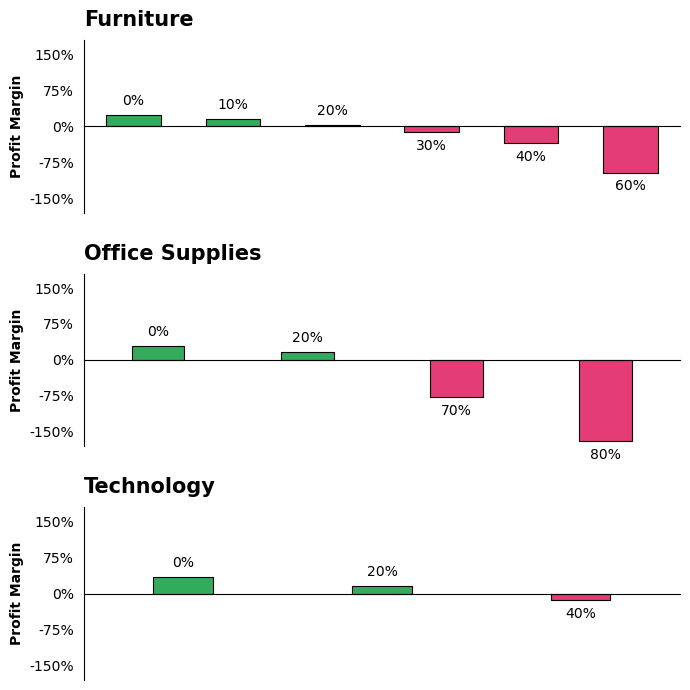

In [5]:
categories = df_agg.index.levels[0].tolist()
data = [df_agg.loc[category] for category in categories]

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(7,7))

title_dict = {'size':15,
              'weight':'bold',
              'color':'black',
              'loc':'left',
              'pad':10,
              'rotation':0,
              'family':plt.rcParams['font.family'],
              'alpha':1}

label_dict = {'y':
              {'size':10,
              'weight':'bold',
              'color':'black',
              'loc':'center',
              'rotation':90,
              'family':plt.rcParams['font.family'],
              'alpha':1}}

for i in range(len(ax)):
    df_plot = data[i]
    palette = ['#ff206e' if margin < 0 else '#20bf55' for margin in df_plot['profit_margin']]
    
    patch = sns.barplot(x=df_plot.index, y=df_plot['profit_margin'], ax=ax[i], palette=palette, ec='black', lw=0.8, alpha=1)
    
    if i == 0:
        for bar in patch.patches:
            bar.set_width(0.55)
            bar.set_xy((bar.get_xy()[0] + 0.125, 0))
    elif i == 1:
        for bar in patch.patches:
            bar.set_width(0.35)
            bar.set_xy((bar.get_xy()[0] + 0.225, 0))
    else:
        for bar in patch.patches:
            bar.set_width(0.3)
            bar.set_xy((bar.get_xy()[0] + 0.25, 0))
    
    ax[i].set_title(f'{categories[i]}', **title_dict)
    ax[i].set_xlabel('')
    ax[i].set_ylabel('Profit Margin', **label_dict['y'])
    
    ax[i].spines['bottom'].set_position(('data', 0))
    ax[i].set_xticklabels('')
    ax[i].set_ylim(-180, 180)
    ax[i].set_yticks(ticks=list(range(-150, 151, 75)))
    ax[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'{y:.0f}%'))
    
    ax[i].tick_params(which='major', axis='both', colors='black', left=False, bottom=False)
    
    container = ax[i].containers[0]
    labels = [f'{discount}%' for discount in df_plot.index]
    ax[i].bar_label(container=container, labels=labels, size=10, weight='normal', color='black', padding=5)
    
    sns.despine(left=False, top=True, right=True, bottom=False, ax=ax[i])

plt.tight_layout()
plt.show()